> Part of **Complete Machine Learning Study Material** — split across per-chapter notebooks. See [`00_index.ipynb`](00_index.ipynb) for the notebook conventions, the per-concept template, the chapter coverage tracker and the cross-reference index.

## 21. Anomaly Detection and Association Rules

*Scope:* Two unsupervised searches for rare joint events - which rows do not belong, and which items occur together more than chance allows - and the ways both mislead.

Two subjects share this chapter because they share a shape: both look for **rare joint events** in data
with no labels, and both are unusually easy to fool yourself with.

Anomaly detection (21.1–21.5) asks *which rows do not belong*. Association rule mining (21.6–21.8) asks
*which items occur together more than chance allows*. In both, the interesting finding is by construction
rare — and rarity is exactly the condition under which a number computed from a handful of observations
looks impressive and means nothing.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_curve, confusion_matrix)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 80
print("ready")

ready


### 21.1 What Counts as an Anomaly

"Anomaly" is not one thing, and the three kinds need different detectors.

| Kind | Definition | Example | Detectable by |
|---|---|---|---|
| **Point** | A single row is extreme on its own | A $40,000 grocery transaction | Everything in this chapter |
| **Contextual** | Normal in general, abnormal *in its context* | 30 °C — in January, in Oslo | Models that see the context feature |
| **Collective** | Each point is fine; the **sequence** is not | 200 small transfers in an hour | Sequence/aggregate models, not row-wise ones |

A second distinction decides which algorithm is even applicable:

| Setting | Training data | Approach |
|---|---|---|
| **Outlier detection** | Contaminated — anomalies are already in it | Fit on everything, flag the odd rows (`IsolationForest`, `LocalOutlierFactor`) |
| **Novelty detection** | **Clean** — guaranteed normal | Learn the boundary of normal, flag departures (`OneClassSVM`, LOF with `novelty=True`) |

In [2]:
def make_anomaly_data(n_normal=480, n_anomalies=20, seed=RANDOM_STATE):
    """Two dense normal clusters plus scattered point anomalies."""
    gen = np.random.default_rng(seed)
    normal = np.vstack([gen.normal([-2, -2], 0.7, (n_normal // 2, 2)),
                        gen.normal([2, 2], 0.7, (n_normal // 2, 2))])
    anomalies = gen.uniform(-7, 7, (n_anomalies, 2))
    X = np.vstack([normal, anomalies])
    y = np.r_[np.zeros(n_normal), np.ones(n_anomalies)].astype(int)  # 1 = anomaly
    return X, y


X_out, y_out = make_anomaly_data()
print(f"{len(X_out)} rows, {y_out.sum()} anomalies ({y_out.mean():.1%})")
print("that 4% rate is already generous - fraud and equipment failure run far below it (22.1)")

500 rows, 20 anomalies (4.0%)
that 4% rate is already generous - fraud and equipment failure run far below it (22.1)


**Contextual anomalies are the ones that get missed**, because a row-wise detector that never sees the
context column cannot possibly find them.

In [3]:
months = rng.integers(0, 12, 400)
seasonal_mean = 15 + 10 * np.sin(2 * np.pi * (months - 3) / 12)     # summer warm, winter cold
temps = rng.normal(seasonal_mean, 2.0)

temps[7], months[7] = 26.0, 0          # 26 C in January: absurd, but not extreme overall
print(f"the planted anomaly: {temps[7]:.1f} C in month {months[7]}")

z = (temps[7] - temps.mean()) / temps.std()
print(f"\nglobal z-score          : {z:>6.2f}   -> not flagged (|z| < 3)")

in_month = temps[months == 0]
z_ctx = (temps[7] - in_month.mean()) / in_month.std()
print(f"z-score within month 0  : {z_ctx:>6.2f}   -> flagged")

the planted anomaly: 26.0 C in month 0

global z-score          :   1.44   -> not flagged (|z| < 3)
z-score within month 0  :   4.35   -> flagged


The same value, the same detector, two different answers — the only thing that changed is whether the model
was allowed to condition on the month. **A contextual anomaly is a modelling decision, not an algorithm
choice**: either the context is in the features or the anomaly is invisible.

### 21.2 Statistical Detection

The oldest methods, and still the right first try when the data is low-dimensional and roughly
well-behaved. 5.3 introduced the first two as *cleaning* tools; here they are the detector itself.

| Method | Flags | Assumes | Breaks when |
|---|---|---|---|
| **z-score** | $\lvert z \rvert > 3$ | Roughly normal, one feature at a time | Skewed data; the outlier inflates $\sigma$ (5.3) |
| **Modified z-score** | $\lvert 0.6745(x - \tilde{x}) / \text{MAD} \rvert > 3.5$ | A symmetric distribution | Heavily skewed data |
| **IQR** | Outside $Q_1 - 1.5\,\text{IQR}$, $Q_3 + 1.5\,\text{IQR}$ | Nothing much — it is rank-based | Multimodal data |
| **Mahalanobis** | $d_M^2$ above a $\chi^2$ quantile | **Multivariate** normal | Non-elliptical clusters; $p$ near $n$ |

Only the last one looks at features jointly, and that difference is the whole point.

In [4]:
# A point can be unremarkable on EVERY feature and still be a clear joint anomaly.
mean = [0, 0]
cov = [[1, 0.95], [0.95, 1]]                                   # strongly correlated
X_corr = rng.multivariate_normal(mean, cov, 400)
X_corr = np.vstack([X_corr, [2.2, -2.2]])                      # off the correlation axis

point = X_corr[-1]
for j, name in enumerate(("feature 0", "feature 1")):
    z = (point[j] - X_corr[:, j].mean()) / X_corr[:, j].std()
    print(f"{name}: value {point[j]:>5.1f}   z = {z:>5.2f}   flagged by |z|>3: {abs(z) > 3}")

feature 0: value   2.2   z =  2.10   flagged by |z|>3: False
feature 1: value  -2.2   z = -2.27   flagged by |z|>3: False


In [5]:
def mahalanobis_sq(X, mean=None, cov=None):
    """Squared Mahalanobis distance: (x-mu)^T S^-1 (x-mu) - Euclidean distance
    measured in units of the data's own spread, along each direction."""
    mean = X.mean(axis=0) if mean is None else mean
    cov = np.cov(X, rowvar=False) if cov is None else cov
    delta = X - mean
    return np.einsum("ij,jk,ik->i", delta, np.linalg.inv(cov), delta)


from scipy.stats import chi2

d2 = mahalanobis_sq(X_corr)
threshold = chi2.ppf(0.99, df=2)                               # 99th percentile of chi-sq with p dof

print(f"Mahalanobis d^2 of the planted point : {d2[-1]:>7.2f}")
print(f"chi-square threshold (p=0.01, df=2)  : {threshold:>7.2f}")
print(f"flagged: {d2[-1] > threshold}")
print(f"\nrows flagged in total: {(d2 > threshold).sum()} of {len(X_corr)}")

Mahalanobis d^2 of the planted point :  125.48
chi-square threshold (p=0.01, df=2)  :    9.21
flagged: True

rows flagged in total: 2 of 401


Both marginal z-scores are around 2 — unremarkable — while the joint distance is enormous. **The anomaly
is not in either feature; it is in the relationship between them**, and no amount of per-column checking
will find it.

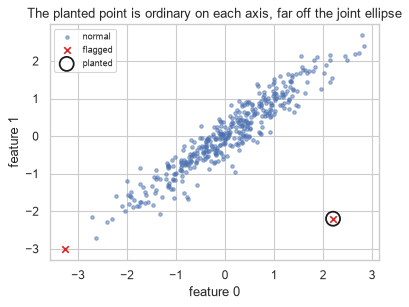

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
flagged = d2 > threshold
ax.scatter(X_corr[~flagged, 0], X_corr[~flagged, 1], s=10, alpha=0.5, label="normal")
ax.scatter(X_corr[flagged, 0], X_corr[flagged, 1], s=35, c="tab:red", marker="x", label="flagged")
ax.scatter(*point, s=160, facecolor="none", edgecolor="k", linewidth=1.6, label="planted")
ax.set_xlabel("feature 0"); ax.set_ylabel("feature 1")
ax.set_title("The planted point is ordinary on each axis, far off the joint ellipse")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

**Common mistake — computing the mean and covariance from contaminated data.** The anomalies sit in the
very sample used to define "normal", so they inflate the covariance and, having widened the ellipse, fall
inside it. This is called **masking**, and it is why robust estimators exist.

One anomaly caught out of sixty, against all sixty for the robust fit — and the reason is in the last two
lines. The contaminated covariance has a determinant some twenty times larger: the outlier blob stretched
the estimate of "normal" until it covered the outlier blob. The **minimum covariance determinant**
estimator behind `EllipticEnvelope` fits on the tightest subset of the data instead, so the anomalies never
enter the definition they are being tested against.

The general principle outlives Mahalanobis distance: **anything that learns "normal" from contaminated data
learns the contamination as normal.** It returns in 21.9.3 as a production failure, where the contamination
arrives one retraining cycle at a time.

In [7]:
N_NORMAL, N_BAD = 250, 60                                      # 19% contamination

X_mask = np.vstack([rng.multivariate_normal([0, 0], [[1, 0.9], [0.9, 1]], N_NORMAL),
                    rng.multivariate_normal([3, -3], [[0.4, 0], [0, 0.4]], N_BAD)])
truth_mask = np.r_[np.zeros(N_NORMAL), np.ones(N_BAD)].astype(int)

d2_classic = mahalanobis_sq(X_mask)                            # mean/cov from EVERYTHING

# Minimum covariance determinant: fit the mean and covariance on the tightest
# subset of the data, so the anomalies never enter the estimate of "normal".
robust = EllipticEnvelope(contamination=0.19, random_state=RANDOM_STATE).fit(X_mask)
d2_robust = robust.mahalanobis(X_mask)

thr = chi2.ppf(0.99, df=2)
print(f"{'estimator':>10}{'anomalies caught':>22}{'AUC':>9}")
for name, d in (("classic", d2_classic), ("robust", d2_robust)):
    caught = ((d > thr) & (truth_mask == 1)).sum()
    print(f"{name:>10}{caught:>15} of {N_BAD}{roc_auc_score(truth_mask, d):>9.4f}")

print(f"\nthe covariance each one learned as 'normal':")
print(f"  classic determinant : {np.linalg.det(np.cov(X_mask, rowvar=False)):.3f}")
print(f"  robust  determinant : {np.linalg.det(robust.covariance_):.3f}")

 estimator      anomalies caught      AUC
   classic              1 of 60   0.8991
    robust             60 of 60   1.0000

the covariance each one learned as 'normal':
  classic determinant : 4.495
  robust  determinant : 0.222


### 21.3 Isolation Forest

Every method so far models what *normal* looks like and measures distance from it. Isolation Forest inverts
the question: **anomalies are easy to separate, so isolate points and see which ones give up quickly.**

Build a tree by repeatedly picking a random feature and a random split value. A point in a dense region
needs many splits before it sits alone; a point out on its own is isolated in a few. The **average path
length** over many such trees is the anomaly score.

This inversion buys three things: no distance metric (so 7.1's curse bites less), no distributional
assumption, and a cost linear in $n$.

$$s(x) = 2^{-\,\mathbb{E}[h(x)] \,/\, c(n)}, \qquad c(n) = 2H_{n-1} - \frac{2(n-1)}{n}$$

$h(x)$ is the path length, and $c(n)$ — the average path length of an unsuccessful search in a binary
search tree — normalizes it so that $s \to 1$ means anomalous and $s \approx 0.5$ means average.

In [8]:
def path_length(x, X_sub, depth=0, max_depth=None, gen=None):
    """Isolate x in a random-split tree built on X_sub; return the depth it took."""
    n = len(X_sub)
    if n <= 1 or depth >= max_depth:
        return depth + c_factor(n)                             # + expected depth of the unbuilt subtree

    feature = gen.integers(X_sub.shape[1])
    lo, hi = X_sub[:, feature].min(), X_sub[:, feature].max()
    if lo == hi:
        return depth + c_factor(n)

    split = gen.uniform(lo, hi)
    side = X_sub[X_sub[:, feature] < split] if x[feature] < split \
        else X_sub[X_sub[:, feature] >= split]
    return path_length(x, side, depth + 1, max_depth, gen)


def c_factor(n):
    """Average path length of an unsuccessful search in a binary search tree."""
    if n <= 1:
        return 0.0
    return 2.0 * (np.log(n - 1) + np.euler_gamma) - 2.0 * (n - 1) / n

In [9]:
def isolation_forest_scores(X, n_trees=100, sample_size=256, seed=0):
    gen = np.random.default_rng(seed)
    sample_size = min(sample_size, len(X))
    max_depth = int(np.ceil(np.log2(sample_size)))             # the paper's height limit

    depths = np.zeros((len(X), n_trees))
    for t in range(n_trees):
        sub = X[gen.choice(len(X), sample_size, replace=False)]
        for i, x in enumerate(X):
            depths[i, t] = path_length(x, sub, 0, max_depth, gen)

    mean_depth = depths.mean(axis=1)
    return 2.0 ** (-mean_depth / c_factor(sample_size))         # higher = more anomalous


scores_mine = isolation_forest_scores(X_out, n_trees=100, sample_size=128, seed=RANDOM_STATE)

print(f"mean score, normal rows    : {scores_mine[y_out == 0].mean():.4f}")
print(f"mean score, planted anomaly: {scores_mine[y_out == 1].mean():.4f}")
print(f"\nranking quality (ROC-AUC)  : {roc_auc_score(y_out, scores_mine):.4f}")

mean score, normal rows    : 0.4562
mean score, planted anomaly: 0.6419

ranking quality (ROC-AUC)  : 0.9765


**Step 4 of the algorithm contract.** scikit-learn's `score_samples` returns the *negated* score, so it has
to be flipped before the two can be compared — and because both are randomized, the right comparison is the
**ranking**, not the values.

In [10]:
from scipy.stats import spearmanr

iso = IsolationForest(n_estimators=100, max_samples=128, contamination=0.04,
                      random_state=RANDOM_STATE).fit(X_out)
scores_sk = -iso.score_samples(X_out)                          # flip: sklearn's is negated

print(f"from-scratch AUC : {roc_auc_score(y_out, scores_mine):.4f}")
print(f"scikit-learn AUC : {roc_auc_score(y_out, scores_sk):.4f}")

rho = spearmanr(scores_mine, scores_sk).statistic
print(f"\nrank correlation between the two score vectors: {rho:.4f}")
print(f"same top-20 flagged rows: "
      f"{len(set(np.argsort(scores_mine)[-20:]) & set(np.argsort(scores_sk)[-20:]))} of 20")

from-scratch AUC : 0.9765
scikit-learn AUC : 0.9794

rank correlation between the two score vectors: 0.9543
same top-20 flagged rows: 19 of 20


`contamination` deserves a note of its own: it does **not** change the scores, only where the threshold
falls when `predict` converts them to a yes/no. Getting it wrong changes how many rows are flagged and
nothing about their ranking.

In [11]:
for c in (0.01, 0.04, 0.10):
    m = IsolationForest(n_estimators=100, max_samples=128, contamination=c,
                        random_state=RANDOM_STATE).fit(X_out)
    pred = m.predict(X_out) == -1                              # -1 is sklearn's "outlier"
    tp = ((pred) & (y_out == 1)).sum()
    print(f"contamination={c:<5}  flagged {pred.sum():>3}   of which real: {tp:>2}/20"
          f"   AUC {roc_auc_score(y_out, -m.score_samples(X_out)):.4f}")

contamination=0.01   flagged   5   of which real:  5/20   AUC 0.9794


contamination=0.04   flagged  20   of which real: 15/20   AUC 0.9794


contamination=0.1    flagged  50   of which real: 18/20   AUC 0.9794


The AUC is identical across all three — the ranking never moved. Only the cut point did. **Set
`contamination` from the rate you can actually afford to investigate**, not from a guess about the true
anomaly rate, which you do not know.

### 21.4 One-Class SVM and Local Outlier Factor

Two more detectors with genuinely different assumptions.

**One-Class SVM** (16.4's kernel machinery, with no labels) learns a boundary enclosing most of the
training data. `nu` bounds the fraction of training points allowed outside it, and with an RBF kernel the
boundary can be any shape. It is a **novelty** detector by design: it assumes the training data is clean,
and degrades when it is not.

**Local Outlier Factor** compares a point's local density with the density of its neighbours. That "local"
is the key word — a point can be dense by global standards and still be an outlier *relative to the cluster
it sits beside*.

| | Isolation Forest | One-Class SVM | LOF |
|---|---|---|---|
| Idea | Easy to isolate | Outside the learned boundary | Lower density than its neighbours |
| Training data | Contaminated is fine | **Wants clean** | Contaminated is fine |
| Scales as | $O(n \log n)$ | $O(n^2)$–$O(n^3)$ | $O(n \log n)$ with a tree |
| Scaling required | No | **Yes** (16.7) | **Yes** |
| Key parameter | `contamination` | `nu`, `gamma` | `n_neighbors` |
| Scores new data | Yes | Yes | **Only with `novelty=True`** |

In [12]:
X_out_scaled = StandardScaler().fit_transform(X_out)

detectors = {
    "IsolationForest": IsolationForest(n_estimators=100, random_state=RANDOM_STATE),
    "OneClassSVM": OneClassSVM(kernel="rbf", nu=0.05, gamma="scale"),
    "LocalOutlierFactor": LocalOutlierFactor(n_neighbors=20),
    "EllipticEnvelope": EllipticEnvelope(contamination=0.04, random_state=RANDOM_STATE),
}

print(f"{'detector':>20}{'ROC-AUC':>10}{'PR-AUC':>9}")
for name, det in detectors.items():
    if isinstance(det, LocalOutlierFactor):
        det.fit(X_out_scaled)
        s = -det.negative_outlier_factor_                      # LOF has no score_samples when fitted this way
    else:
        s = -det.fit(X_out_scaled).score_samples(X_out_scaled)
    print(f"{name:>20}{roc_auc_score(y_out, s):>10.4f}{average_precision_score(y_out, s):>9.4f}")

            detector   ROC-AUC   PR-AUC


     IsolationForest    0.9830   0.8415
         OneClassSVM    0.9872   0.8204
  LocalOutlierFactor    0.9915   0.9271
    EllipticEnvelope    0.9912   0.8967


**LOF's local view is what the others lack.** Build two clusters of very different density and put an
outlier beside the tight one. Measured against the whole dataset the planted point is at an ordinary
distance — the sparse cluster's own members are spread further apart than that. LOF compares it only with
its twenty nearest neighbours, which are all from the tight cluster, and reaches a different verdict.

In [13]:
tight = rng.normal([0, 0], 0.25, (200, 2))                     # dense
loose = rng.normal([5, 5], 1.6, (200, 2))                      # sparse
planted = np.array([[1.2, 1.2]])                               # near the tight cluster, but not in it

X_lof = np.vstack([tight, loose, planted])
truth_lof = np.r_[np.zeros(400), [1]].astype(int)

lof_scores = -LocalOutlierFactor(n_neighbors=20).fit(X_lof).negative_outlier_factor_
iso_scores = -IsolationForest(n_estimators=200,
                              random_state=RANDOM_STATE).fit(X_lof).score_samples(X_lof)
env_scores = EllipticEnvelope(contamination=0.02,
                              random_state=RANDOM_STATE).fit(X_lof).mahalanobis(X_lof)

for name, s in (("LOF (local)", lof_scores), ("IsolationForest", iso_scores),
                ("Mahalanobis (global)", env_scores)):
    rank = (-s).argsort().tolist().index(len(X_lof) - 1) + 1   # 1 = most anomalous
    print(f"{name:>22}: the planted point ranks {rank:>3} of {len(X_lof)}")

           LOF (local): the planted point ranks   1 of 401
       IsolationForest: the planted point ranks  10 of 401
  Mahalanobis (global): the planted point ranks 201 of 401


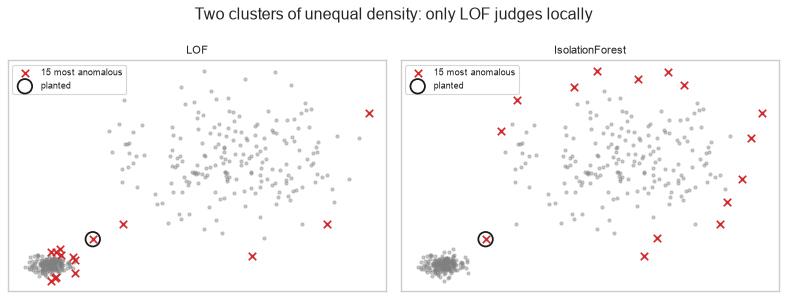

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, (name, s) in zip(axes, (("LOF", lof_scores), ("IsolationForest", iso_scores))):
    top = np.argsort(s)[-15:]
    ax.scatter(X_lof[:, 0], X_lof[:, 1], s=8, alpha=0.4, c="gray")
    ax.scatter(X_lof[top, 0], X_lof[top, 1], s=45, c="tab:red", marker="x",
               label="15 most anomalous")
    ax.scatter(*planted[0], s=170, facecolor="none", edgecolor="k", linewidth=1.6,
               label="planted")
    ax.set_title(name, fontsize=10); ax.legend(fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Two clusters of unequal density: only LOF judges locally")
fig.tight_layout()
plt.show()

Three methods, three verdicts on the same point, and the ordering is exactly what each one's definition
predicts. Mahalanobis measures distance from a single global ellipse, so a point at middling distance gets
a middling rank. Isolation Forest notices that the point sits in a gap and ranks it tenth. Only LOF, which
compares the point's density with the density of its own neighbours, puts it first.

**In practice** — the four-detector table above is close enough that it should not decide anything on its
own; on data shaped differently the order changes. As a default first try on tabular data with no strong
prior, `IsolationForest` is the safe choice: it needs no scaling, no distance metric and no clean training
set, and it is the only one of the four that stays cheap as $n$ grows. Reach for LOF when densities
genuinely vary across the space, as they did here, and for One-Class SVM when there is a certified-clean
reference period to learn "normal" from.

### 21.5 Evaluating a Detector

The evaluation problem here is 20.8's, made worse: not only is there usually no ground truth, but when
there is, it is extremely imbalanced. 8.6's warning about ROC-AUC applies with full force.

| Metric | Use when | Watch out |
|---|---|---|
| **ROC-AUC** | Comparing rankings, balanced-ish costs | **Looks good at any imbalance** — the false-positive rate has a huge denominator |
| **PR-AUC / average precision** | The positive class is rare — the default here | Baseline is the positive rate, not 0.5 |
| **Precision@k** | You can investigate exactly $k$ per day | Directly operational; the metric to report |
| **Recall at fixed precision** | A false-positive budget is fixed | Requires labelled anomalies |

**Common mistake — reporting ROC-AUC on a 0.5% anomaly rate.** At that imbalance a detector whose flagged
set is overwhelmingly false positives still scores well, because the false-positive rate is divided by a
very large number of negatives.

In [15]:
n_rare, rate = 20_000, 0.005
y_rare = (rng.random(n_rare) < rate).astype(int)

# A mediocre detector: anomalies score slightly higher on average, with heavy overlap.
s_rare = rng.normal(0, 1, n_rare) + 1.6 * y_rare

print(f"{y_rare.sum()} anomalies in {n_rare} rows ({y_rare.mean():.2%})")
print(f"\nROC-AUC          : {roc_auc_score(y_rare, s_rare):.4f}   <- looks respectable")
print(f"PR-AUC (avg prec): {average_precision_score(y_rare, s_rare):.4f}   <- the honest number")
print(f"PR-AUC baseline  : {y_rare.mean():.4f}   (a random scorer)")

119 anomalies in 20000 rows (0.60%)

ROC-AUC          : 0.8613   <- looks respectable
PR-AUC (avg prec): 0.0589   <- the honest number
PR-AUC baseline  : 0.0060   (a random scorer)


In [16]:
# What an analyst actually experiences: they can work through the top k alerts per day.
order = np.argsort(s_rare)[::-1]

print(f"{'k':>7}{'true anomalies':>17}{'precision@k':>14}{'recall@k':>11}")
for k in (20, 50, 100, 500):
    hits = y_rare[order[:k]].sum()
    print(f"{k:>7}{hits:>17}{hits / k:>14.3f}{hits / y_rare.sum():>11.3f}")

      k   true anomalies   precision@k   recall@k
     20                3         0.150      0.025
     50                7         0.140      0.059
    100               13         0.130      0.109
    500               35         0.070      0.294


An ROC-AUC of 0.86 next to a precision@50 of 0.14 is the normal state of affairs, not a contradiction: the
detector really does rank anomalies above normal rows most of the time, and an analyst working the top 50
alerts still finds that six in seven are false. Both numbers are correct; only one of them describes
somebody's day.

**Report precision@k**, with $k$ set to the number of alerts the team can actually work through. Note also
how recall@k moves: to catch even 30% of the anomalies the team would have to work 500 alerts to find 35.
That ratio, not the AUC, is what determines whether the detector gets deployed.

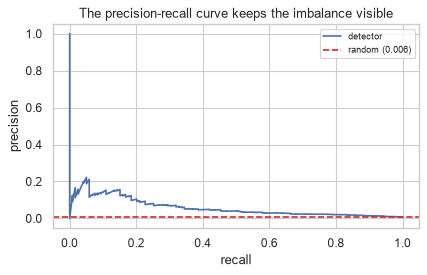

In [17]:
fig, ax = plt.subplots(figsize=(5.5, 3.6))
precision, recall, _ = precision_recall_curve(y_rare, s_rare)
ax.plot(recall, precision, label="detector")
ax.axhline(y_rare.mean(), color="tab:red", ls="--", label=f"random ({y_rare.mean():.3f})")
ax.set_xlabel("recall"); ax.set_ylabel("precision")
ax.set_title("The precision-recall curve keeps the imbalance visible")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### 21.6 Association Rule Mining: the Setup

The second half of the chapter. **Market-basket analysis** asks which items co-occur in transactions more
often than independence would predict — the canonical output being rules of the form
$\{\text{bread}\} \Rightarrow \{\text{jam}\}$.

The vocabulary is small and worth fixing before any arithmetic:

| Term | Is |
|---|---|
| **Transaction** | One basket — a set of items, with no order and no counts |
| **Itemset** | Any set of items, e.g. $\{\text{bread}, \text{jam}\}$ |
| **$k$-itemset** | An itemset of size $k$ |
| **Frequent itemset** | One whose support clears a threshold |
| **Rule** $A \Rightarrow B$ | An itemset split into antecedent $A$ and consequent $B$, disjoint |

The data must first be reshaped from long form into a **one-hot basket matrix**: one row per transaction,
one boolean column per item.

In [18]:
tx = pd.read_csv("data/transactions.csv")
print(tx.head(5).to_string(index=False))
print(f"\n{len(tx)} rows, {tx['transaction_id'].nunique()} baskets, {tx['item'].nunique()} distinct items")

transaction_id      item
         T0001   lentils
         T0001  tomatoes
         T0002 chocolate
         T0002     sugar
         T0002       tea

2622 rows, 800 baskets, 20 distinct items


In [19]:
baskets = tx.groupby("transaction_id")["item"].apply(list)

print(f"basket size: mean {baskets.apply(len).mean():.2f}, "
      f"median {baskets.apply(len).median():.0f}, max {baskets.apply(len).max()}")
print("\nthree baskets:")
for tid, items in baskets.head(3).items():
    print(f"  {tid}: {sorted(items)}")

basket size: mean 3.28, median 3, max 11

three baskets:
  T0001: ['lentils', 'tomatoes']
  T0002: ['chocolate', 'sugar', 'tea', 'tomatoes', 'yogurt']
  T0003: ['biscuits', 'butter', 'cheese', 'sugar', 'tea']


In [20]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
basket_matrix = pd.DataFrame(te.fit_transform(baskets.tolist()), columns=te.columns_)

print(f"basket matrix: {basket_matrix.shape[0]} transactions x {basket_matrix.shape[1]} items")
print(f"density: {basket_matrix.to_numpy().mean():.1%} of cells are True")
print()
print(basket_matrix.iloc[:4, :6].to_string())

basket matrix: 800 transactions x 20 items
density: 16.4% of cells are True

   bananas  biscuits  bread  butter  cereal  cheese
0    False     False  False   False   False   False
1    False     False  False   False   False   False
2    False      True  False    True   False    True
3    False     False  False   False   False   False


That 16% density is the structural fact the algorithms in 21.8 exploit. Real retail baskets are far
sparser still — thousands of products, a handful per basket — which is why the naive approach of
enumerating every itemset is hopeless: 20 items already give $2^{20}$ subsets.

In [21]:
print(f"{'items':>8}{'possible itemsets':>22}")
for n_items in (20, 100, 1_000, 10_000):
    print(f"{n_items:>8}{f'2^{n_items} ~ 10^{int(n_items * np.log10(2))}':>22}")
print("\nenumerating all of them is not an option - 21.8 is about avoiding it")

   items     possible itemsets
      20           2^20 ~ 10^6
     100         2^100 ~ 10^30
    1000       2^1000 ~ 10^301
   10000     2^10000 ~ 10^3010

enumerating all of them is not an option - 21.8 is about avoiding it


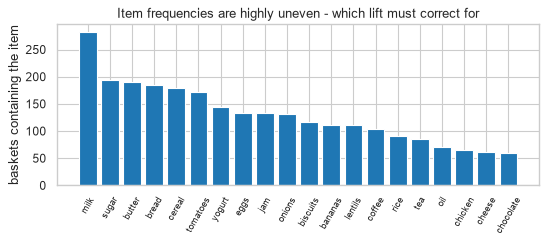

most common : milk in 35.2% of baskets
least common: chocolate in 7.5%


In [22]:
item_counts = basket_matrix.sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(item_counts.index, item_counts.values, color="tab:blue")
ax.set_ylabel("baskets containing the item")
ax.set_title("Item frequencies are highly uneven - which lift must correct for")
ax.tick_params(axis="x", rotation=60, labelsize=8)
fig.tight_layout()
plt.show()

print(f"most common : {item_counts.index[0]} in {item_counts.iloc[0] / len(basket_matrix):.1%} of baskets")
print(f"least common: {item_counts.index[-1]} in {item_counts.iloc[-1] / len(basket_matrix):.1%}")

### 21.7 Support, Confidence, Lift and Conviction

Four measures of a rule $A \Rightarrow B$, each answering a different question. All of them are needed;
none of them is sufficient alone.

$$\text{support}(A \Rightarrow B) = P(A \cap B) \qquad
\text{confidence}(A \Rightarrow B) = P(B \mid A) = \frac{P(A \cap B)}{P(A)}$$

$$\text{lift}(A \Rightarrow B) = \frac{P(B \mid A)}{P(B)} \qquad
\text{conviction}(A \Rightarrow B) = \frac{1 - P(B)}{1 - P(B \mid A)}$$

| Measure | Answers | Range | Independence at | Blind to |
|---|---|---|---|---|
| **Support** | How often does this happen at all? | $[0, 1]$ | — | Whether it is interesting |
| **Confidence** | Given $A$, how often $B$? | $[0, 1]$ | $P(B)$ | **How common $B$ is anyway** |
| **Lift** | How much more than chance? | $[0, \infty)$ | **1** | Direction; small-sample noise |
| **Conviction** | How often would the rule be wrong if $A, B$ were independent? | $[0, \infty)$ | **1** | — |

Lift is symmetric: $\text{lift}(A \Rightarrow B) = \text{lift}(B \Rightarrow A)$. Confidence and conviction
are not.

In [23]:
def rule_metrics(matrix, antecedent, consequent):
    """All four measures for one rule, computed directly from the boolean matrix."""
    A = matrix[list(antecedent)].all(axis=1)
    Bc = matrix[list(consequent)].all(axis=1)

    p_a, p_b = A.mean(), Bc.mean()
    support = (A & Bc).mean()
    confidence = support / p_a
    lift = confidence / p_b
    conviction = np.inf if confidence == 1 else (1 - p_b) / (1 - confidence)

    return {"support": support, "confidence": confidence, "lift": lift,
            "conviction": conviction, "P(B)": p_b}


print(pd.DataFrame({
    "onions => milk": rule_metrics(basket_matrix, ["onions"], ["milk"]),
    "cereal => yogurt": rule_metrics(basket_matrix, ["cereal"], ["yogurt"]),
}).T.round(3).to_string())

                  support  confidence   lift  conviction   P(B)
onions => milk      0.055       0.333  0.946       0.971  0.352
cereal => yogurt    0.080       0.356  1.962       1.270  0.181


**This is the confidence trap, in two rows.** The two rules have near-identical confidence — 0.33 against
0.36 — so ranked on confidence alone they look equally useful.

They are not remotely equal. Milk is in 35% of all baskets, so a rule that predicts milk a third of the
time has learned nothing: its lift sits just **below** 1, meaning onion buyers are, if anything, very
slightly *less* likely to buy milk than a random shopper. Yogurt is in 18% of baskets, so the same
confidence represents a genuine doubling, and the lift of 1.96 says so.

**Confidence alone will always favour popular consequents.** A rule "$\Rightarrow$ milk" is close to
guaranteed high confidence and close to guaranteed worthless.

In [24]:
# Taken to its extreme: a rule whose consequent is in nearly every basket.
synthetic = basket_matrix.copy()
synthetic["bag"] = True                                        # every customer takes a bag
synthetic.loc[:9, "bag"] = False

print(pd.DataFrame({
    "bread => bag": rule_metrics(synthetic, ["bread"], ["bag"]),
    "bread => jam": rule_metrics(synthetic, ["bread"], ["jam"]),
}).T.round(3).to_string())
print("\nconfidence 1.00, lift 1.01, conviction infinite: perfectly predictable, perfectly useless.")
print("conviction goes to infinity precisely because confidence hit 1 - a rule that is")
print("never wrong looks infinitely strong, even when it is telling you nothing.")

              support  confidence   lift  conviction   P(B)
bread => bag    0.230         1.0  1.013         inf  0.988
bread => jam    0.115         0.5  3.008       1.668  0.166

confidence 1.00, lift 1.01, conviction infinite: perfectly predictable, perfectly useless.
conviction goes to infinity precisely because confidence hit 1 - a rule that is
never wrong looks infinitely strong, even when it is telling you nothing.


**The second trap is the opposite one: enormous lift on a handful of baskets.** Lift has no notion of
sample size, so the rarest itemsets produce the most spectacular numbers.

In [25]:
n_baskets = len(basket_matrix)
print(f"{'rule support':>15}{'baskets':>10}{'max possible lift':>20}")
for s in (0.0025, 0.01, 0.05, 0.15):
    k = int(s * n_baskets)
    print(f"{s:>15.4f}{k:>10}{1 / s:>20.1f}")
print("\nA rule seen in 2 baskets can show a lift in the hundreds. That is arithmetic, not insight.")

   rule support   baskets   max possible lift
         0.0025         2               400.0
         0.0100         8               100.0
         0.0500        40                20.0
         0.1500       120                 6.7

A rule seen in 2 baskets can show a lift in the hundreds. That is arithmetic, not insight.


### 21.8 Apriori and FP-Growth

21.6 showed that enumerating all itemsets is impossible. **Apriori** makes it tractable with one
observation, the *downward closure* or **apriori property**:

> If an itemset is frequent, every one of its subsets is frequent.
> Equivalently: **if any subset is infrequent, the itemset cannot be frequent.**

So the search proceeds level by level — find frequent 1-itemsets, form 2-itemset candidates only from
those, count, prune, repeat — and entire branches are eliminated without ever being counted.

In [26]:
from itertools import combinations


def apriori_from_scratch(matrix, min_support):
    """Level-wise frequent itemset mining. Returns {itemset: support}."""
    columns = list(matrix.columns)
    values = matrix.to_numpy()
    n = len(values)
    col_index = {c: i for i, c in enumerate(columns)}

    def support(itemset):
        cols = [col_index[i] for i in itemset]
        return values[:, cols].all(axis=1).sum() / n

    frequent = {}
    current = [(c,) for c in columns if support((c,)) >= min_support]
    frequent.update({frozenset(s): support(s) for s in current})

    k = 2
    while current:
        # Candidates: unions of size k whose every (k-1)-subset is already frequent.
        candidates = set()
        for a, b in combinations(current, 2):
            union = tuple(sorted(set(a) | set(b)))
            if len(union) == k and all(
                    frozenset(sub) in frequent for sub in combinations(union, k - 1)):
                candidates.add(union)                           # THE PRUNING STEP

        current = [c for c in candidates if support(c) >= min_support]
        frequent.update({frozenset(s): support(s) for s in current})
        k += 1

    return frequent

In [27]:
MIN_SUPPORT = 0.05

t0 = time.perf_counter()
mine = apriori_from_scratch(basket_matrix, MIN_SUPPORT)
elapsed_mine = time.perf_counter() - t0

sizes = pd.Series([len(s) for s in mine]).value_counts().sort_index()
print(f"{len(mine)} frequent itemsets at min_support={MIN_SUPPORT}, in {elapsed_mine:.3f}s")
print("\nby size:")
for k, count in sizes.items():
    print(f"  {k}-itemsets: {count}")

43 frequent itemsets at min_support=0.05, in 0.003s

by size:
  1-itemsets: 20
  2-itemsets: 21
  3-itemsets: 2


**How much did pruning actually save?** Count the candidates Apriori considered against the number it would
have had to count by brute force.

In [28]:
n_items = basket_matrix.shape[1]
brute_force = 2 ** n_items - 1

print(f"items                                   : {n_items}")
print(f"all non-empty itemsets (brute force)    : {brute_force:,}")
print(f"frequent itemsets actually found        : {len(mine)}")
print(f"\nApriori never counts an itemset whose subsets failed, so the vast majority of")
print(f"those {brute_force:,} are eliminated without a single pass over the data.")

items                                   : 20
all non-empty itemsets (brute force)    : 1,048,575
frequent itemsets actually found        : 43

Apriori never counts an itemset whose subsets failed, so the vast majority of
those 1,048,575 are eliminated without a single pass over the data.


**Step 4 of the contract** — the from-scratch itemsets against `mlxtend`'s.

In [29]:
from mlxtend.frequent_patterns import apriori, fpgrowth

lib = apriori(basket_matrix, min_support=MIN_SUPPORT, use_colnames=True)
lib_map = {frozenset(s): v for s, v in zip(lib["itemsets"], lib["support"])}

print(f"from scratch : {len(mine)} itemsets")
print(f"mlxtend      : {len(lib_map)} itemsets")
print(f"\nsame itemsets : {set(mine) == set(lib_map)}")
print(f"same supports : {np.allclose([mine[s] for s in mine], [lib_map[s] for s in mine])}")

from scratch : 43 itemsets
mlxtend      : 43 itemsets

same itemsets : True
same supports : True


#### 21.8.1 FP-Growth

Apriori's weakness is that it scans the data once per level. **FP-Growth** avoids that by compressing the
transactions into a prefix tree (the FP-tree) and mining it recursively — two passes over the data,
regardless of the longest itemset.

| | Apriori | FP-Growth |
|---|---|---|
| Data passes | One per level | **Two** |
| Candidate generation | Explicit, level-wise | **None** — patterns are grown from the tree |
| Memory | Low | Holds the tree |
| Faster when | Few levels, high threshold | **Low thresholds, long patterns** |

Both return **exactly the same itemsets** — FP-Growth is an optimization, not a different definition.

In [30]:
results = {}
for name, fn in (("apriori", apriori), ("fpgrowth", fpgrowth)):
    t0 = time.perf_counter()
    out = fn(basket_matrix, min_support=0.01, use_colnames=True)
    results[name] = (time.perf_counter() - t0, out)
    print(f"{name:>10}: {len(out):>4} itemsets in {results[name][0]:.3f}s")

a_sets = {frozenset(s) for s in results["apriori"][1]["itemsets"]}
f_sets = {frozenset(s) for s in results["fpgrowth"][1]["itemsets"]}
print(f"\nidentical itemsets: {a_sets == f_sets}")

   apriori:  459 itemsets in 0.010s
  fpgrowth:  459 itemsets in 0.011s

identical itemsets: True


#### 21.8.2 From itemsets to rules

Frequent itemsets are not yet rules. Each frequent itemset of size $k \geq 2$ is split every possible way
into antecedent and consequent, and the splits are filtered on a metric.

In [31]:
from mlxtend.frequent_patterns import association_rules

frequent = apriori(basket_matrix, min_support=0.05, use_colnames=True)
rules = association_rules(frequent, metric="lift", min_threshold=1.2)

rules["A"] = rules["antecedents"].apply(lambda s: ", ".join(sorted(s)))
rules["B"] = rules["consequents"].apply(lambda s: ", ".join(sorted(s)))
top = rules.sort_values("lift", ascending=False).head(10)

print(f"{len(rules)} rules with lift > 1.2 at support >= 0.05\n")
print(top[["A", "B", "support", "confidence", "lift", "conviction"]]
      .round(3).to_string(index=False))

36 rules with lift > 1.2 at support >= 0.05

            A             B  support  confidence  lift  conviction
      lentils          rice    0.068       0.486 4.324       1.728
         rice       lentils    0.068       0.600 4.324       2.153
  butter, jam         bread    0.065       0.881 3.832       6.490
        bread   butter, jam    0.065       0.283 3.832       1.291
bread, butter           jam    0.065       0.500 3.008       1.668
          jam bread, butter    0.065       0.391 3.008       1.429
        bread           jam    0.115       0.500 3.008       1.668
          jam         bread    0.115       0.692 3.008       2.498
 milk, yogurt        cereal    0.076       0.656 2.915       2.252
       cereal  milk, yogurt    0.076       0.339 2.915       1.337


**Common mistake — sorting by lift and reading the top of the table.** At a low support threshold that
table is dominated by rules resting on a handful of baskets, exactly as 21.7 predicted.

In [32]:
loose_rules = association_rules(
    apriori(basket_matrix, min_support=0.01, use_colnames=True),
    metric="lift", min_threshold=1.0).sort_values("lift", ascending=False)

loose_rules["A"] = loose_rules["antecedents"].apply(lambda s: ", ".join(sorted(s)))
loose_rules["B"] = loose_rules["consequents"].apply(lambda s: ", ".join(sorted(s)))
loose_rules["baskets"] = (loose_rules["support"] * len(basket_matrix)).astype(int)

print("top of the table, sorted by lift, min_support = 0.01:\n")
print(loose_rules[["A", "B", "baskets", "support", "confidence", "lift"]]
      .head(6).round(3).to_string(index=False))
print(f"\nevery one of those rests on {loose_rules['baskets'].head(6).max()} baskets or fewer,"
      f" out of {len(basket_matrix)}.")

top of the table, sorted by lift, min_support = 0.01:

                      A                       B  baskets  support  confidence   lift
             milk, rice cereal, lentils, yogurt        8     0.01       0.333 26.667
cereal, lentils, yogurt              milk, rice        8     0.01       0.800 26.667
    butter, jam, onions         bread, tomatoes        8     0.01       0.889 22.222
        bread, tomatoes     butter, jam, onions        8     0.01       0.250 22.222
bread, butter, tomatoes             jam, onions        8     0.01       0.471 19.814
            jam, onions bread, butter, tomatoes        8     0.01       0.421 19.814

every one of those rests on 8 baskets or fewer, out of 800.


### 21.9 In Practice

#### 21.9.1 A worked case: which rules would you actually act on?

The request: *"Find product pairings we can use for shelf placement and bundle offers."*

A rules table is trivially easy to generate and almost always unusable as produced. The work is in the
filtering, and every filter below removes rules that a lift-sorted table would have put at the top.

In [33]:
MIN_BASKETS = 30                                               # the smallest evidence we will act on
min_support = MIN_BASKETS / len(basket_matrix)

frequent = fpgrowth(basket_matrix, min_support=min_support, use_colnames=True)
candidates = association_rules(frequent, metric="lift", min_threshold=1.0)

print(f"min_support {min_support:.4f} ({MIN_BASKETS} baskets) -> "
      f"{len(frequent)} itemsets, {len(candidates)} rules")

min_support 0.0375 (30 baskets) -> 68 itemsets, 78 rules


**Filter 1 — the rule must beat chance by a margin worth acting on**, and it must be *reliable*, not just
directionally right.

In [34]:
kept = candidates[(candidates["lift"] >= 1.5) & (candidates["confidence"] >= 0.30)].copy()
print(f"lift >= 1.5 and confidence >= 0.30: {len(kept)} rules remain of {len(candidates)}")

lift >= 1.5 and confidence >= 0.30: 35 rules remain of 78


**Filter 2 — drop redundant rules.** If $\{A\} \Rightarrow \{B\}$ already holds, then
$\{A, C\} \Rightarrow \{B\}$ adds nothing unless it is *substantially* stronger. Left unfiltered, one real
association generates dozens of near-duplicate rows and swamps the table.

In [35]:
def is_redundant(row, table, tolerance=0.05):
    """True if some rule with a SUBSET antecedent and the same consequent is as strong."""
    a, c = row["antecedents"], row["consequents"]
    simpler = table[
        table["antecedents"].apply(lambda x: x < a)            # strict subset
        & (table["consequents"] == c)
    ]
    return bool((simpler["confidence"] >= row["confidence"] - tolerance).any())


kept["redundant"] = kept.apply(is_redundant, axis=1, table=kept)
final = kept[~kept["redundant"]].copy()

print(f"redundant rules dropped: {kept['redundant'].sum()}")
print(f"rules remaining        : {len(final)}")

redundant rules dropped: 4
rules remaining        : 31


**Filter 3 — pick a direction.** Lift is symmetric, so every association appears twice, once each way. Only
one direction is actionable, and which one depends on the decision: for a "customers who bought $A$ also
bought $B$" prompt, keep the direction with the higher **confidence**, because that is the one whose
prediction is more often right.

In [36]:
final["pair"] = final.apply(
    lambda r: frozenset(r["antecedents"] | r["consequents"]), axis=1)

# Within each item-pair, keep only the higher-confidence direction.
actionable = (final.sort_values("confidence", ascending=False)
                   .drop_duplicates("pair")
                   .sort_values("lift", ascending=False))

actionable["A"] = actionable["antecedents"].apply(lambda s: ", ".join(sorted(s)))
actionable["B"] = actionable["consequents"].apply(lambda s: ", ".join(sorted(s)))
actionable["baskets"] = (actionable["support"] * len(basket_matrix)).astype(int)

print(f"{len(final)} rules -> {len(actionable)} after dropping the weaker direction\n")
print(actionable[["A", "B", "baskets", "support", "confidence", "lift", "conviction"]]
      .round(3).to_string(index=False))

31 rules -> 16 after dropping the weaker direction



             A        B  baskets  support  confidence  lift  conviction
          rice  lentils       54    0.068       0.600 4.324       2.153
   butter, jam    bread       52    0.065       0.881 3.832       6.490
           tea biscuits       38    0.048       0.442 3.047       1.532
           jam    bread       92    0.115       0.692 3.008       2.498
   milk, sugar   cereal       39    0.049       0.672 2.989       2.366
milk, tomatoes   cereal       31    0.039       0.660 2.931       2.277
        coffee    sugar       69    0.086       0.663 2.736       2.251
        onions tomatoes       77    0.096       0.583 2.729       1.887
cereal, yogurt     milk       61    0.076       0.953 2.704      13.813
         bread   butter      104    0.130       0.565 2.367       1.751
        cereal     milk      141    0.176       0.783 2.222       2.988
           tea    sugar       45    0.056       0.523 2.158       1.589
        yogurt   cereal       64    0.080       0.441 1.962    

**Step 4 — turn a rule into a number someone can decide on.** "Lift 3.0" is not a business case. The
question a category manager asks is *how many extra units would this move*.

In [37]:
def uplift_estimate(matrix, antecedent, consequent, n_shoppers=10_000):
    """If every buyer of A were exposed to B, how many extra B-purchases over baseline?"""
    m = rule_metrics(matrix, antecedent, consequent)
    buyers_of_a = n_shoppers * matrix[list(antecedent)].all(axis=1).mean()

    expected_if_independent = buyers_of_a * m["P(B)"]
    observed = buyers_of_a * m["confidence"]
    return {"A buyers": round(buyers_of_a),
            "B if independent": round(expected_if_independent),
            "B observed": round(observed),
            "excess": round(observed - expected_if_independent)}


print(pd.DataFrame({
    "bread => jam": uplift_estimate(basket_matrix, ["bread"], ["jam"]),
    "rice => lentils": uplift_estimate(basket_matrix, ["rice"], ["lentils"]),
    "bread => milk": uplift_estimate(basket_matrix, ["bread"], ["milk"]),
}).T.to_string())

                 A buyers  B if independent  B observed  excess
bread => jam         2300               382        1150     768
rice => lentils      1125               156         675     519
bread => milk        2300               811         562    -248


**Step 5 — the finding, and its limits.**

> **What the data supports.** The filters cut 78 candidate rules to a table of durable ones, each resting
> on at least 30 baskets rather than the 8 that the lift-sorted table of 21.8.2 was built on. The
> strongest are `rice ⇒ lentils` (lift 4.3), the bread–butter–jam group (lift 3.0–3.8), `biscuits ⇒ tea`
> and the milk–cereal–yogurt group. These are the candidates worth a shelf test.
>
> **What it is worth.** Per 10,000 shoppers the bread–jam association represents roughly 770 jam purchases
> above what independence predicts, and rice–lentils about 520. Those are the numbers to take to a
> category manager. "Lift 3.0" is not a business case; "768 incremental units per 10,000 shoppers" is.
>
> **The rule to reject.** `bread ⇒ milk` reaches a plausible-looking confidence and an uplift that is
> **negative** — 248 *fewer* milk purchases than independence predicts, and a lift below 1. Bread buyers
> are slightly less likely to buy milk, not more. A confidence-sorted table would have put this rule in
> contention; lift and the uplift estimate both reject it.
>
> **The critical caveat: this is association, not causation.** Nothing here says moving jam next to bread
> *causes* jam sales. Customers who buy both may simply be making the same kind of shopping trip. The
> finding identifies a hypothesis worth an **A/B test** (23.7 for how to run the comparison honestly), and
> the test is what would justify the shelf change.
>
> **And the baskets are not a random sample of shoppers** — they are a sample of *trips*. A customer who
> shops four times a week is in the data four times as often, so these rules describe frequent shoppers
> more than they describe customers.

#### 21.9.2 When to reach for this — and when not

| Situation | Use | Not |
|---|---|---|
| Labelled anomalies exist, enough of them | **A classifier** (Ch. 11–19) with class weights (22.4) | Unsupervised detection |
| No labels, tabular, mixed feature scales | **IsolationForest** (21.3) | Distance methods without scaling |
| Densities vary across the space | **LOF** (21.4) | Global methods |
| A certified-clean training period exists | **OneClassSVM**, LOF `novelty=True` | Outlier methods that assume contamination |
| Roughly elliptical, low-dimensional | **Mahalanobis / EllipticEnvelope** (21.2) | Isolation Forest — you are discarding known structure |
| The anomaly is a *sequence*, not a row | Aggregate to the entity, then detect | Row-wise detectors |
| High-dimensional data | Reduce first (7.5), or use Isolation Forest | LOF, One-Class SVM (7.1) |
| Co-occurrence in transactions | **FP-Growth** (21.8.1), then filter hard | A lift-sorted table read from the top |
| You want to predict a *specific* item | A classifier with that item as target | Association rules |
| Fewer than a few hundred transactions | Nothing — describe the frequencies | Rule mining; there is no support to be had |

#### 21.9.3 What goes wrong in production

| Failure | What it looks like | Where |
|---|---|---|
| **Alert fatigue** | `contamination` set too high; the team stops reading the alerts | 21.3 |
| **ROC-AUC on the dashboard** | 0.94 reported while precision@50 is 0.2 | 21.5 |
| **Masking** | Detector retrained on data containing last month's anomalies; they become normal | 21.2 |
| **The threshold drifts** | Score distribution moves; the fixed cut flags 10x more or nothing | 24.9 |
| **Rules never re-mined** | Seasonal pairings mined in December applied all year | 21.9.1 |
| **Rules read as causal** | Shelves rearranged; nothing changes | 21.9.1 |
| **Contamination treated as truth** | The flagged count mistaken for the real anomaly count | 21.3 |

The fourth row is the most common silent failure, and the reason to monitor the **score distribution**
rather than only the flag count.

In [38]:
# A detector trained on last month, scoring this month - after the population shifted.
train = rng.normal(0, 1, (2000, 3))
detector = IsolationForest(n_estimators=200, contamination=0.02,
                           random_state=RANDOM_STATE).fit(train)

cut = np.percentile(-detector.score_samples(train), 98)        # the frozen threshold

print(f"{'shift':>8}{'flagged':>10}{'median score':>15}")
for shift in (0.0, 0.3, 0.6, 1.0):
    month = rng.normal(shift, 1, (2000, 3))
    s = -detector.score_samples(month)
    print(f"{shift:>8.1f}{(s > cut).mean():>10.2%}{np.median(s):>15.4f}")

   shift   flagged   median score
     0.0     1.85%         0.4385
     0.3     3.10%         0.4460
     0.6     6.20%         0.4682
     1.0    17.65%         0.5116


Nothing in that table is an error and nothing raises a warning. The population moved, the frozen threshold
did not, and the flag rate went from the 2% it was tuned for to nearly 18% — which an on-call team
experiences as a flood.

The two columns answer different questions, and both belong on the monitor (24.9). **The flag rate is the
alarm**: it moves fastest and it is what the team feels. **The median score is the diagnosis**: it drifts
steadily upward across the whole population, which is the signature of *everything* having moved rather
than of genuine anomalies appearing. If real anomalies were arriving, the flag rate would climb while the
median stayed put. Distinguishing those two cases is the entire reason to log the score distribution and
not just the alert count.

In [39]:
# --- 21. Anomaly Detection and Association Rules — scratch cell ---
# Experiments for this chapter. Promote anything worth keeping into the
# relevant section as a proper example cell.

